In [1]:
import sys
sys.path.append('../')

from BPMQ import *
import numpy as np
import datetime
import matplotlib.pyplot as plt
from flame_utils import ModelFlame
from epics import caget

In [2]:
machineIO = construct_machineIO()
machineIO._test = False
machineIO._check_chopper_blocking = False
machineIO._fetch_data_time_span = 6
machineIO._ensure_set_timewait_after_ramp = 0.25
machineIO._fetch_data_resample_rate = 0.2

E_MeVu = 175
Charge_number = 20

SCS = caget("ACS_DIAG:DEST:ACTIVE_ION_SOURCE")
Mass_number = caget("FE_ISRC"+str(SCS)+":BEAM:A_BOOK")
Ion = caget("FE_ISRC"+str(SCS)+":BEAM:ELMT_BOOK")

FLAMEfile = "flame_reconst_input_20250226_00_48Ca20+.lat"  # Replace with your lattice file
from_elem = "BDS_BTS:QV_D5501"
to_elem = "BDS_BTS:PM_D5567"

In [3]:
fname = datetime.datetime.now().strftime('%Y%m%d_%H%M')+f'_{Mass_number}{Ion}{Charge_number}+_BPMQscan_TIS161'
fname

'20250226_0322_48Ca20+_BPMQscan_TIS161'

In [4]:
lattice_dicts = fmlat.combine_lattice_elements_quads_only(FLAMEfile, from_element=from_elem, to_element=to_elem)
for elem_dic in lattice_dicts:
    elem_dic['name'] = fmlat.fmname2mpname(elem_dic['name'])
qnames = [elem['name'] for elem in lattice_dicts if elem['type']=='quadrupole']
qnames = qnames[-4:-2]
qnames

['BDS_BTS:PSQ_D5501', 'BDS_BTS:PSQ_D5509']

In [5]:
fm = ModelFlame(FLAMEfile)
from_index = fm.get_element(from_elem)[0]['index']
r,s = fm.run(to_element=from_index-1)
alfx,betx = s.get_twiss('x')[:2]
emitxn = s.xnemittance
alfy,bety = s.get_twiss('y')[:2]
emityn = s.ynemittance

cs_ref = [alfx, betx, emitxn*1e-6,alfy, bety, emityn*1e-6]
cs_ref

[-3.7026266229490896,
 21.916082993951377,
 5.754009737477061e-07,
 0.23082760990744372,
 8.739429635139988,
 4.03489198434486e-07]

In [6]:
args = (E_MeVu, Mass_number, Charge_number)
kwargs = {
    "lattice_dicts" : lattice_dicts,
    "quads_to_scan": qnames,
    "quads_max_curr": [180, 180, 180, 180],
    "quads_min_curr": [ 10,  10,  10,  10],
    "xnemit_target": emitxn,
    "ynemit_target": emityn,
    "BPM_names":["BDS_BTS:BPM_D5513", "BDS_BTS:BPM_D5565"],
    "BPMQ_model_type":"TISRAW_GP",
    "ISAAC_preset_keywords":["BDS"],
    "machineIO": machineIO,
    "bootstrap":False,
    "plot_history":True, 
    "plot_ellipse":True,
    "set_manually":True,
    "correct_traj_each_iter":False,
    "cs_ref": cs_ref, #None,
}

self.fetch_data_monitors ['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD', 'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD', 'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD', 'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD', 'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET', 'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET', 'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD', 'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD', 'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD', 'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSC1_D5563:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_3_RD', 'BDS_BTS:PSC2_D5563:I_RD', 'BDS_BTS:BPM_D5565:CURRENT_RD', 'BDS_BTS:PSC1_D5563:I_CSET', 'BDS_BTS:BPM_D5565:YPOS_RD', 'BDS_BTS:PSC1_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISRAW3_RD', 'BDS_BTS:BPM_D5513:YPOS_RD', 'BDS_BTS:BPM_D5513:TISRAW

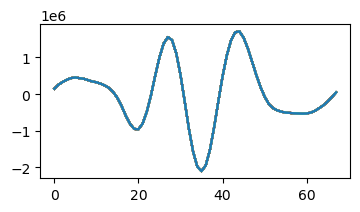

xy_.shape torch.Size([41, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): S

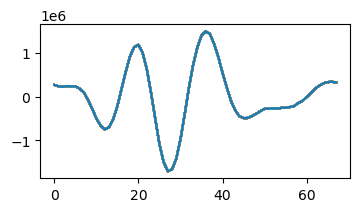

xy_.shape torch.Size([41, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:23:00.800,13.228413,8.784286
2025-02-26 08:23:01.000,13.228113,8.784093
2025-02-26 08:23:01.200,13.228044,8.784165
2025-02-26 08:23:01.400,13.179035,8.848697
2025-02-26 08:23:01.600,13.178854,8.847953
2025-02-26 08:23:01.800,13.178756,8.847504
2025-02-26 08:23:02.000,13.178386,8.847441
2025-02-26 08:23:02.200,13.178227,8.847639
2025-02-26 08:23:02.400,13.123675,8.857164


ISAAC preset:


,BDS_BTS:PSQ_D5501:I_CSET,BDS_BTS:PSQ_D5509:I_CSET
1,75.188870,80.758416
2,75.188870,102.775528
3,75.188870,124.792639
6,124.792639,83.108068
7,95.378474,83.108068
8,66.051334,83.108068


init_llB2 tensor([[ -4.6243,   6.6368],
        [ -8.9163,   9.5768],
        [ -8.9163,  12.1877],
        [ -8.9163,  14.7986],
        [-14.7986,   9.8554],
        [-11.3105,   9.8554],
        [ -7.8327,   9.8554]])
init_llB2 tensor([[ -4.6243,   6.6368],
        [ -8.9163,   9.5768],
        [ -8.9163,  12.1877],
        [ -8.9163,  14.7986],
        [-14.7986,   9.8554],
        [-11.3105,   9.8554],
        [ -7.8327,   9.8554]])


,BDS_BTS:PSQ_D5501:I_CSET,BDS_BTS:PSQ_D5509:I_CSET
0,38.995,55.966001


ensure_set(['BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSQ_D5509:I_CSET'],['BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:PSQ_D5509:I_RD'],[38.99500035971309, 55.96600136099503],tol=[0.2, 0.2, 0.2, 0.2],timeout=20)
Set the above PVs and press any key to continue...
self.fetch_data_monitors ['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD', 'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD', 'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD', 'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD', 'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET', 'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET', 'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD', 'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD', 'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD', 'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSC1_D5563:I_RD', 'BDS_BTS:BPM_D5513

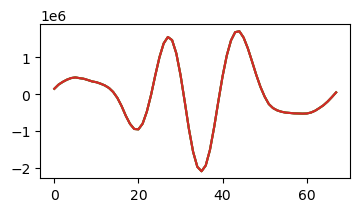

xy_.shape torch.Size([4, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Se

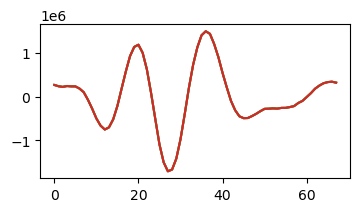

xy_.shape torch.Size([4, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:23:16.800,13.197784,8.812553
2025-02-26 08:23:17.000,13.196672,8.812711
2025-02-26 08:23:17.200,13.195487,8.812429
2025-02-26 08:23:17.400,13.210275,8.926018


raw2Q_processor called
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Sequenti

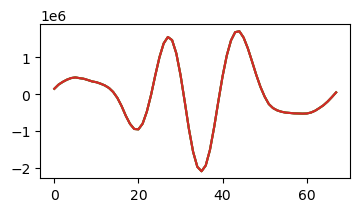

xy_.shape torch.Size([4, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Se

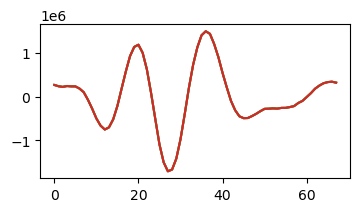

xy_.shape torch.Size([4, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:23:16.800,13.197784,8.812553
2025-02-26 08:23:17.000,13.196672,8.812711
2025-02-26 08:23:17.200,13.195487,8.812429
2025-02-26 08:23:17.400,13.210275,8.926018


BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.915367
BDS_BTS:BPM_D5565:MAG_RD    1.860870
dtype: float64
self.init_BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.912809
BDS_BTS:BPM_D5565:MAG_RD    1.858389
dtype: float64
df.columns Index(['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD',
       'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD',
       'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD',
       'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD',
       'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET',
       'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET',
       'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD',
       'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD',
       'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD',
       'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD',
       'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET',
       'BDS_BTS:PSC1_D556

,BDS_BTS:BPM_D5513:beamQ_model_err,BDS_BTS:BPM_D5565:beamQ_model_err
timestamp,,
2025-02-26 08:23:16.800,6.158831,5.623504
2025-02-26 08:23:17.000,6.158807,5.624445
2025-02-26 08:23:17.200,6.158803,5.626645
2025-02-26 08:23:17.400,6.162755,5.618794


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
,13.200055,8.840928


,BDS_BTS:PSQ_D5501:I_CSET,BDS_BTS:PSQ_D5509:I_CSET
0,75.188869,80.758417


ensure_set(['BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSQ_D5509:I_CSET'],['BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:PSQ_D5509:I_RD'],[75.18886904027072, 80.75841727793967],tol=[0.2, 0.2, 0.2, 0.2],timeout=20)
Set the above PVs and press any key to continue...
self.fetch_data_monitors ['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD', 'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD', 'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD', 'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD', 'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET', 'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET', 'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD', 'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD', 'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD', 'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSC1_D5563:I_RD', 'BDS_BTS:BPM_D5513

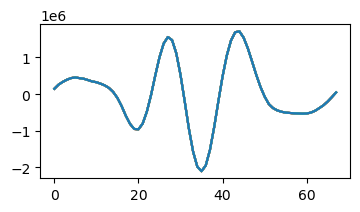

xy_.shape torch.Size([11, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): S

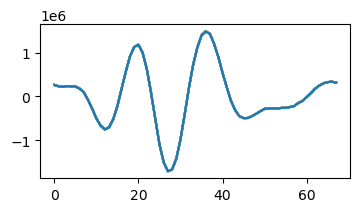

xy_.shape torch.Size([11, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:23:27.600,13.184697,8.815566
2025-02-26 08:23:27.800,13.183860,8.815499
2025-02-26 08:23:28.000,13.183054,8.814980
2025-02-26 08:23:28.200,13.181940,8.814075
2025-02-26 08:23:28.400,13.190800,8.738025
2025-02-26 08:23:28.600,13.191109,8.737933
2025-02-26 08:23:28.800,13.192380,8.737682
2025-02-26 08:23:29.000,13.193071,8.737672
2025-02-26 08:23:29.200,13.194173,8.737957


raw2Q_processor called
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Sequenti

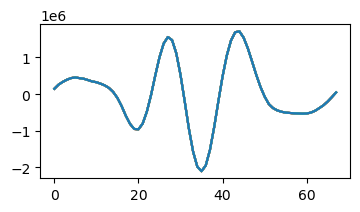

xy_.shape torch.Size([11, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): S

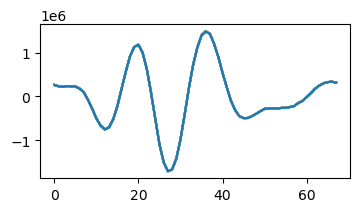

xy_.shape torch.Size([11, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:23:27.600,13.184697,8.815566
2025-02-26 08:23:27.800,13.183860,8.815499
2025-02-26 08:23:28.000,13.183054,8.814980
2025-02-26 08:23:28.200,13.181940,8.814075
2025-02-26 08:23:28.400,13.190800,8.738025
2025-02-26 08:23:28.600,13.191109,8.737933
2025-02-26 08:23:28.800,13.192380,8.737682
2025-02-26 08:23:29.000,13.193071,8.737672
2025-02-26 08:23:29.200,13.194173,8.737957


BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.914191
BDS_BTS:BPM_D5565:MAG_RD    1.859692
dtype: float64
self.init_BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.914600
BDS_BTS:BPM_D5565:MAG_RD    1.860126
dtype: float64
df.columns Index(['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD',
       'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD',
       'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD',
       'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD',
       'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET',
       'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET',
       'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD',
       'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD',
       'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD',
       'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD',
       'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET',
       'BDS_BTS:PSC1_D556

,BDS_BTS:BPM_D5513:beamQ_model_err,BDS_BTS:BPM_D5565:beamQ_model_err
timestamp,,
2025-02-26 08:23:27.600,6.181834,5.636455
2025-02-26 08:23:27.800,6.181813,5.636828
2025-02-26 08:23:28.000,6.181805,5.639762
2025-02-26 08:23:28.200,6.181806,5.643192
2025-02-26 08:23:28.400,6.153892,5.669035
2025-02-26 08:23:28.600,6.153891,5.669158
2025-02-26 08:23:28.800,6.153899,5.669005
2025-02-26 08:23:29.000,6.153910,5.666637
2025-02-26 08:23:29.200,6.153943,5.664052


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
,13.193967,8.776523


,BDS_BTS:PSQ_D5501:I_CSET,BDS_BTS:PSQ_D5509:I_CSET
0,75.188869,102.775525


ensure_set(['BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSQ_D5509:I_CSET'],['BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:PSQ_D5509:I_RD'],[75.18886904027072, 102.77552458661906],tol=[0.2, 0.2, 0.2, 0.2],timeout=20)
Set the above PVs and press any key to continue...
self.fetch_data_monitors ['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD', 'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD', 'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD', 'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD', 'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET', 'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET', 'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD', 'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD', 'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD', 'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSC1_D5563:I_RD', 'BDS_BTS:BPM_D551

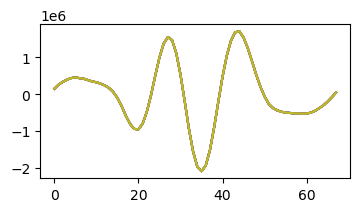

xy_.shape torch.Size([9, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Se

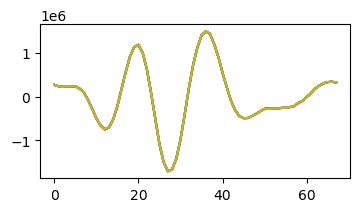

xy_.shape torch.Size([9, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:24:25.600,13.347528,8.579704
2025-02-26 08:24:25.800,13.346531,8.578601
2025-02-26 08:24:26.000,13.345911,8.577821
2025-02-26 08:24:26.200,13.345633,8.577330
2025-02-26 08:24:26.400,13.168393,8.631929
2025-02-26 08:24:26.600,13.167567,8.631618
2025-02-26 08:24:26.800,13.167680,8.631717
2025-02-26 08:24:27.000,13.168157,8.632670
2025-02-26 08:24:27.200,13.168046,8.633545


raw2Q_processor called
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Sequenti

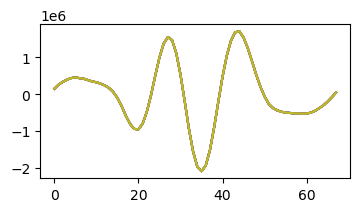

xy_.shape torch.Size([9, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Se

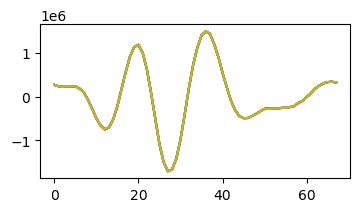

xy_.shape torch.Size([9, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:24:25.600,13.347528,8.579704
2025-02-26 08:24:25.800,13.346531,8.578601
2025-02-26 08:24:26.000,13.345911,8.577821
2025-02-26 08:24:26.200,13.345633,8.577330
2025-02-26 08:24:26.400,13.168393,8.631929
2025-02-26 08:24:26.600,13.167567,8.631618
2025-02-26 08:24:26.800,13.167680,8.631717
2025-02-26 08:24:27.000,13.168157,8.632670
2025-02-26 08:24:27.200,13.168046,8.633545


BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.912172
BDS_BTS:BPM_D5565:MAG_RD    1.857544
dtype: float64
self.init_BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.914314
BDS_BTS:BPM_D5565:MAG_RD    1.859822
dtype: float64
df.columns Index(['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD',
       'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD',
       'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD',
       'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD',
       'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET',
       'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET',
       'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD',
       'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD',
       'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD',
       'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD',
       'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET',
       'BDS_BTS:PSC1_D556

,BDS_BTS:BPM_D5513:beamQ_model_err,BDS_BTS:BPM_D5565:beamQ_model_err
timestamp,,
2025-02-26 08:24:25.600,6.016884,5.681717
2025-02-26 08:24:25.800,6.016819,5.685998
2025-02-26 08:24:26.000,6.016788,5.690138
2025-02-26 08:24:26.200,6.016777,5.693994
2025-02-26 08:24:26.400,6.124992,5.675979
2025-02-26 08:24:26.600,6.124971,5.678643
2025-02-26 08:24:26.800,6.124971,5.678179
2025-02-26 08:24:27.000,6.124978,5.674246
2025-02-26 08:24:27.200,6.124972,5.670111


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
,13.247272,8.608326


,BDS_BTS:PSQ_D5501:I_CSET,BDS_BTS:PSQ_D5509:I_CSET
0,75.188869,124.79264


ensure_set(['BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSQ_D5509:I_CSET'],['BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:PSQ_D5509:I_RD'],[75.18886904027072, 124.79263993736349],tol=[0.2, 0.2, 0.2, 0.2],timeout=20)
Set the above PVs and press any key to continue...
self.fetch_data_monitors ['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD', 'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD', 'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD', 'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD', 'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET', 'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET', 'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD', 'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD', 'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD', 'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSC1_D5563:I_RD', 'BDS_BTS:BPM_D551

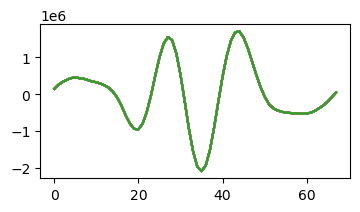

xy_.shape torch.Size([23, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): S

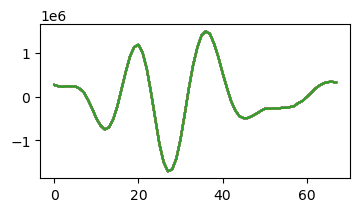

xy_.shape torch.Size([23, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:24:31.400,13.134072,8.591644
2025-02-26 08:24:31.600,13.134661,8.591768
2025-02-26 08:24:31.800,13.134632,8.592076
2025-02-26 08:24:32.000,13.135271,8.593158
2025-02-26 08:24:32.200,13.136191,8.592659
2025-02-26 08:24:32.400,13.218068,8.544687
2025-02-26 08:24:32.600,13.218453,8.544664
2025-02-26 08:24:32.800,13.218795,8.544880
2025-02-26 08:24:33.000,13.218935,8.544698


raw2Q_processor called
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Sequenti

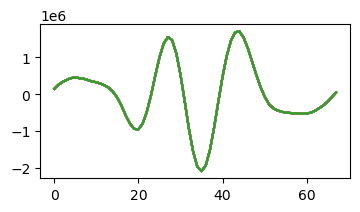

xy_.shape torch.Size([23, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): S

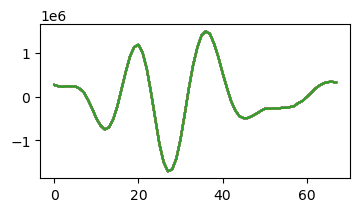

xy_.shape torch.Size([23, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:24:31.400,13.134072,8.591644
2025-02-26 08:24:31.600,13.134661,8.591768
2025-02-26 08:24:31.800,13.134632,8.592076
2025-02-26 08:24:32.000,13.135271,8.593158
2025-02-26 08:24:32.200,13.136191,8.592659
2025-02-26 08:24:32.400,13.218068,8.544687
2025-02-26 08:24:32.600,13.218453,8.544664
2025-02-26 08:24:32.800,13.218795,8.544880
2025-02-26 08:24:33.000,13.218935,8.544698


BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.910885
BDS_BTS:BPM_D5565:MAG_RD    1.856430
dtype: float64
self.init_BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.912815
BDS_BTS:BPM_D5565:MAG_RD    1.858227
dtype: float64
df.columns Index(['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD',
       'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD',
       'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD',
       'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD',
       'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET',
       'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET',
       'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD',
       'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD',
       'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD',
       'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD',
       'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET',
       'BDS_BTS:PSC1_D556

,BDS_BTS:BPM_D5513:beamQ_model_err,BDS_BTS:BPM_D5565:beamQ_model_err
timestamp,,
2025-02-26 08:24:31.400,6.144645,5.705886
2025-02-26 08:24:31.600,6.144622,5.705892
2025-02-26 08:24:31.800,6.144621,5.704868
2025-02-26 08:24:32.000,6.144599,5.701636
2025-02-26 08:24:32.200,6.144577,5.701241
2025-02-26 08:24:32.400,6.087755,5.716698
2025-02-26 08:24:32.600,6.087749,5.716108
2025-02-26 08:24:32.800,6.087745,5.715041
2025-02-26 08:24:33.000,6.087744,5.715303


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
,13.171925,8.531947


,BDS_BTS:PSQ_D5501:I_CSET,BDS_BTS:PSQ_D5509:I_CSET
0,124.79264,83.108067


ensure_set(['BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSQ_D5509:I_CSET'],['BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:PSQ_D5509:I_RD'],[124.79263993736349, 83.10806742493186],tol=[0.2, 0.2, 0.2, 0.2],timeout=20)
Set the above PVs and press any key to continue...
self.fetch_data_monitors ['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD', 'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD', 'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD', 'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD', 'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET', 'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET', 'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD', 'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD', 'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD', 'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSC1_D5563:I_RD', 'BDS_BTS:BPM_D551

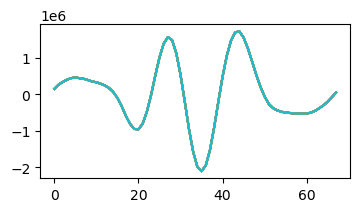

xy_.shape torch.Size([10, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): S

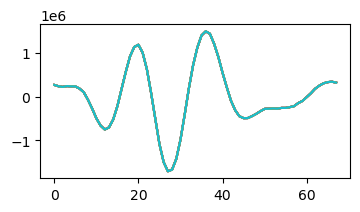

xy_.shape torch.Size([10, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:24:42.200,13.179356,8.638321
2025-02-26 08:24:42.400,13.107328,8.563909
2025-02-26 08:24:42.600,13.108257,8.563244
2025-02-26 08:24:42.800,13.109157,8.562668
2025-02-26 08:24:43.000,13.109616,8.562477
2025-02-26 08:24:43.200,13.109525,8.562428
2025-02-26 08:24:43.400,13.018137,8.519891
2025-02-26 08:24:43.600,13.018081,8.520322
2025-02-26 08:24:43.800,13.017567,8.520417


raw2Q_processor called
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Sequenti

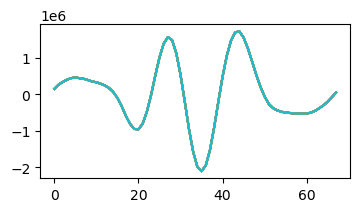

xy_.shape torch.Size([10, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): S

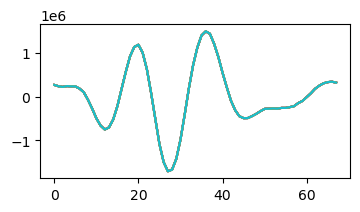

xy_.shape torch.Size([10, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:24:42.200,13.179356,8.638321
2025-02-26 08:24:42.400,13.107328,8.563909
2025-02-26 08:24:42.600,13.108257,8.563244
2025-02-26 08:24:42.800,13.109157,8.562668
2025-02-26 08:24:43.000,13.109616,8.562477
2025-02-26 08:24:43.200,13.109525,8.562428
2025-02-26 08:24:43.400,13.018137,8.519891
2025-02-26 08:24:43.600,13.018081,8.520322
2025-02-26 08:24:43.800,13.017567,8.520417


BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.917743
BDS_BTS:BPM_D5565:MAG_RD    1.863130
dtype: float64
self.init_BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.911464
BDS_BTS:BPM_D5565:MAG_RD    1.856969
dtype: float64
df.columns Index(['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD',
       'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD',
       'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD',
       'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD',
       'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET',
       'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET',
       'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD',
       'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD',
       'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD',
       'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD',
       'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET',
       'BDS_BTS:PSC1_D556

,BDS_BTS:BPM_D5513:beamQ_model_err,BDS_BTS:BPM_D5565:beamQ_model_err
timestamp,,
2025-02-26 08:24:42.200,6.139291,5.690401
2025-02-26 08:24:42.400,6.165959,5.689847
2025-02-26 08:24:42.600,6.165975,5.688647
2025-02-26 08:24:42.800,6.166002,5.688845
2025-02-26 08:24:43.000,6.166020,5.687428
2025-02-26 08:24:43.200,6.166017,5.686644
2025-02-26 08:24:43.400,6.215095,5.691220
2025-02-26 08:24:43.600,6.215092,5.691220
2025-02-26 08:24:43.800,6.215085,5.691541


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
,13.079441,8.553371


,BDS_BTS:PSQ_D5501:I_CSET,BDS_BTS:PSQ_D5509:I_CSET
0,95.378473,83.108067


ensure_set(['BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSQ_D5509:I_CSET'],['BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:PSQ_D5509:I_RD'],[95.37847335975563, 83.10806742493186],tol=[0.2, 0.2, 0.2, 0.2],timeout=20)
Set the above PVs and press any key to continue...
self.fetch_data_monitors ['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD', 'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD', 'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD', 'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD', 'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET', 'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET', 'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD', 'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD', 'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD', 'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSC1_D5563:I_RD', 'BDS_BTS:BPM_D5513

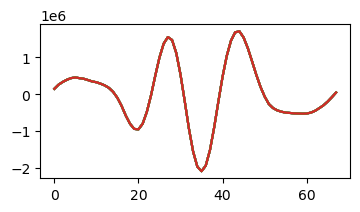

xy_.shape torch.Size([14, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): S

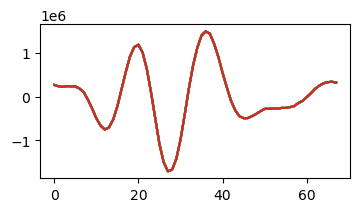

xy_.shape torch.Size([14, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:24:49.600,13.220305,8.433936
2025-02-26 08:24:49.800,13.219332,8.433848
2025-02-26 08:24:50.000,13.219688,8.433592
2025-02-26 08:24:50.200,13.220254,8.432545
2025-02-26 08:24:50.400,13.115802,8.424324
2025-02-26 08:24:50.600,13.116406,8.425778
2025-02-26 08:24:50.800,13.116947,8.424651
2025-02-26 08:24:51.000,13.116630,8.423997
2025-02-26 08:24:51.200,13.115184,8.424004


raw2Q_processor called
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Sequenti

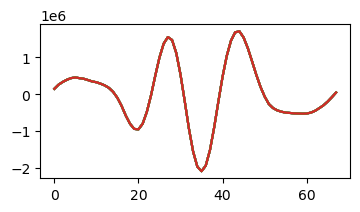

xy_.shape torch.Size([14, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): S

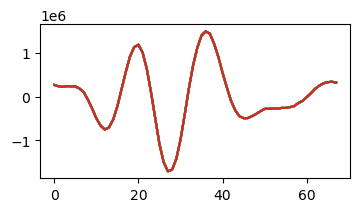

xy_.shape torch.Size([14, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:24:49.600,13.220305,8.433936
2025-02-26 08:24:49.800,13.219332,8.433848
2025-02-26 08:24:50.000,13.219688,8.433592
2025-02-26 08:24:50.200,13.220254,8.432545
2025-02-26 08:24:50.400,13.115802,8.424324
2025-02-26 08:24:50.600,13.116406,8.425778
2025-02-26 08:24:50.800,13.116947,8.424651
2025-02-26 08:24:51.000,13.116630,8.423997
2025-02-26 08:24:51.200,13.115184,8.424004


BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.914260
BDS_BTS:BPM_D5565:MAG_RD    1.859702
dtype: float64
self.init_BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.915860
BDS_BTS:BPM_D5565:MAG_RD    1.861282
dtype: float64
df.columns Index(['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD',
       'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD',
       'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD',
       'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD',
       'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET',
       'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET',
       'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD',
       'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD',
       'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD',
       'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD',
       'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET',
       'BDS_BTS:PSC1_D556

,BDS_BTS:BPM_D5513:beamQ_model_err,BDS_BTS:BPM_D5565:beamQ_model_err
timestamp,,
2025-02-26 08:24:49.600,6.093458,5.769897
2025-02-26 08:24:49.800,6.093486,5.772081
2025-02-26 08:24:50.000,6.093478,5.773864
2025-02-26 08:24:50.200,6.093463,5.776688
2025-02-26 08:24:50.400,6.159446,5.776196
2025-02-26 08:24:50.600,6.159444,5.771794
2025-02-26 08:24:50.800,6.159447,5.772852
2025-02-26 08:24:51.000,6.159446,5.773330
2025-02-26 08:24:51.200,6.159456,5.773998


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
,13.128645,8.450354


,BDS_BTS:PSQ_D5501:I_CSET,BDS_BTS:PSQ_D5509:I_CSET
0,66.051334,83.108067


ensure_set(['BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSQ_D5509:I_CSET'],['BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:PSQ_D5509:I_RD'],[66.05133398913574, 83.10806742493186],tol=[0.2, 0.2, 0.2, 0.2],timeout=20)
Set the above PVs and press any key to continue...
self.fetch_data_monitors ['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD', 'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD', 'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD', 'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD', 'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET', 'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET', 'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD', 'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD', 'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD', 'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSC1_D5563:I_RD', 'BDS_BTS:BPM_D5513

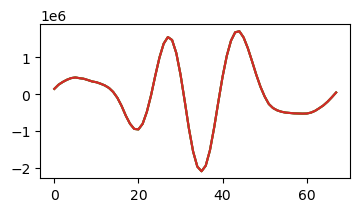

xy_.shape torch.Size([4, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Se

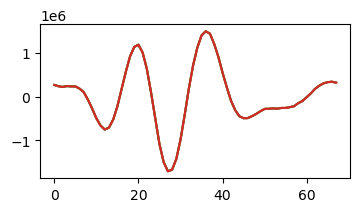

xy_.shape torch.Size([4, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:24:59.400,13.103029,8.353109
2025-02-26 08:24:59.600,13.104439,8.354090
2025-02-26 08:24:59.800,13.105020,8.356229
2025-02-26 08:25:00.000,13.105042,8.356903


raw2Q_processor called
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Sequenti

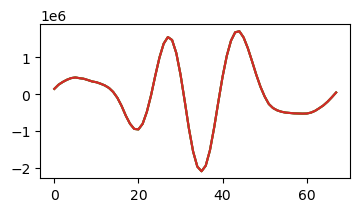

xy_.shape torch.Size([4, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Se

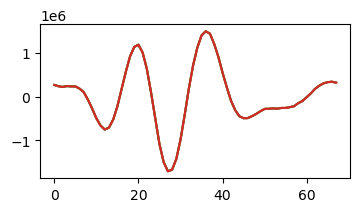

xy_.shape torch.Size([4, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:24:59.400,13.103029,8.353109
2025-02-26 08:24:59.600,13.104439,8.354090
2025-02-26 08:24:59.800,13.105020,8.356229
2025-02-26 08:25:00.000,13.105042,8.356903


BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.909781
BDS_BTS:BPM_D5565:MAG_RD    1.856207
dtype: float64
self.init_BPM_MAGs BDS_BTS:BPM_D5513:MAG_RD    1.914740
BDS_BTS:BPM_D5565:MAG_RD    1.860176
dtype: float64
df.columns Index(['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD',
       'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD',
       'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD',
       'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD',
       'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET',
       'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET',
       'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD',
       'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD',
       'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD',
       'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD',
       'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET',
       'BDS_BTS:PSC1_D556

,BDS_BTS:BPM_D5513:beamQ_model_err,BDS_BTS:BPM_D5565:beamQ_model_err
timestamp,,
2025-02-26 08:24:59.400,6.161397,5.811992
2025-02-26 08:24:59.600,6.161340,5.808599
2025-02-26 08:24:59.800,6.161320,5.803111
2025-02-26 08:25:00.000,6.161317,5.800624


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
,13.104383,8.355083


after init, number of training data is 7
 ======== cs_reconstruct ========
BPMQ_tolerances tensor([[0.5198, 0.4745],
        [0.5202, 0.4771],
        [0.5128, 0.4794],
        [0.5164, 0.4819],
        [0.5218, 0.4802],
        [0.5192, 0.4867],
        [0.5199, 0.4900]])
BPMQ_tolerances.shape torch.Size([7, 2])


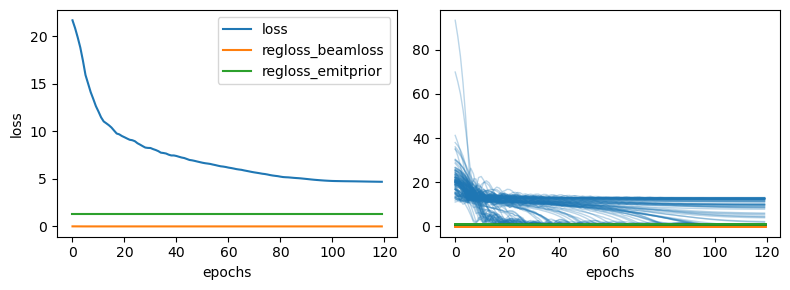

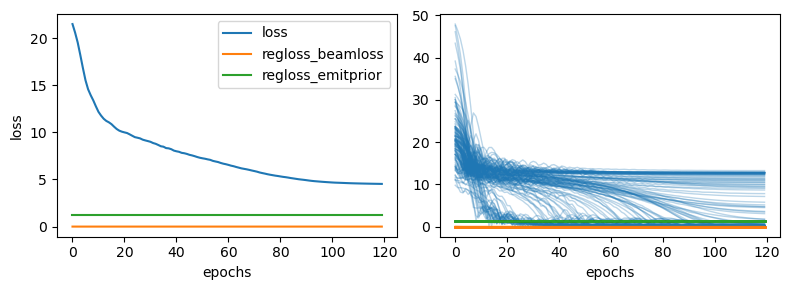

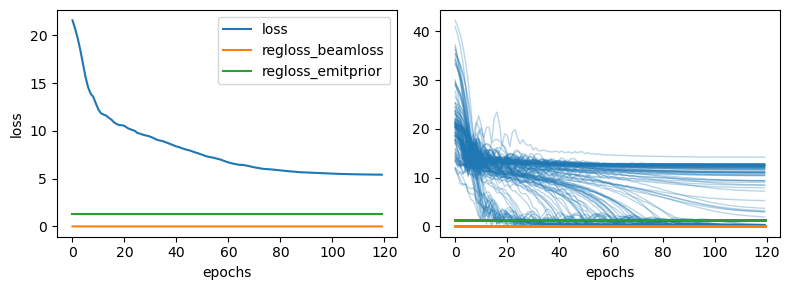

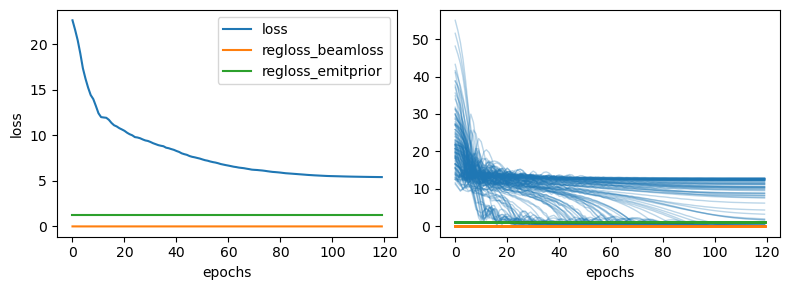

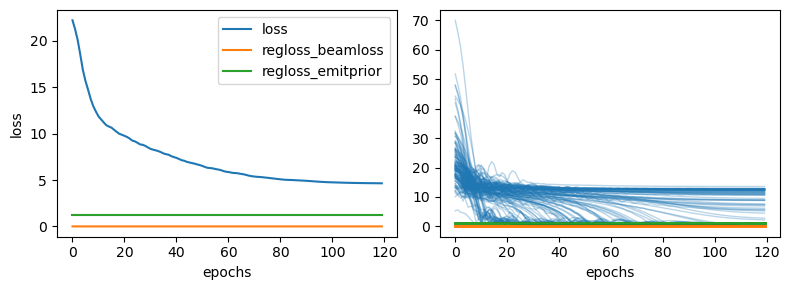

 ======== query_candidate_quad_set_maximizing_BPMQ_var ========
Exiting early at iteration 1 due to large loss


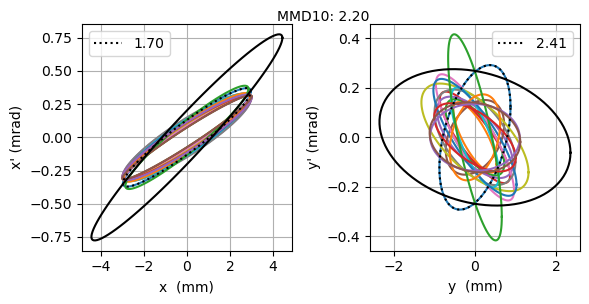

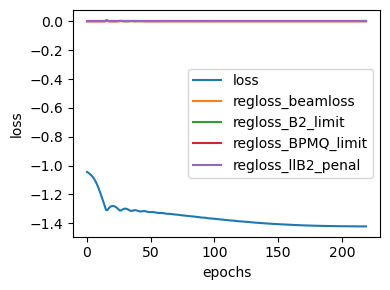

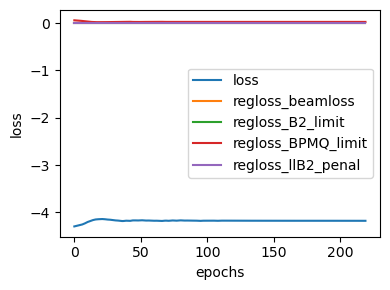

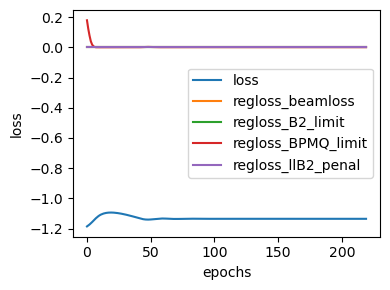

Exiting early at iteration 1 due to large loss
Exiting early at iteration 1 due to large loss


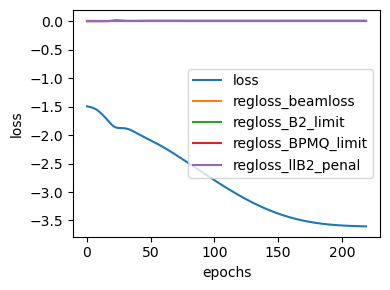

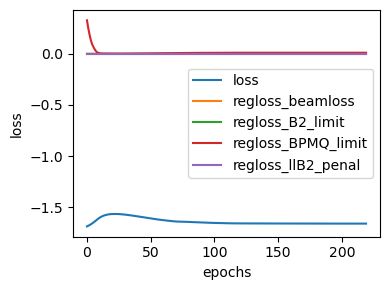

best_loss tensor(-1.4181)
best_regloss_beamloss 0.0


,BDS_BTS:PSQ_D5501:I_CSET,BDS_BTS:PSQ_D5509:I_CSET
0,123.992269,94.302188


ensure_set(['BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSQ_D5509:I_CSET'],['BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:PSQ_D5509:I_RD'],[123.99226949693805, 94.30218770937311],tol=[0.2, 0.2, 0.2, 0.2],timeout=20)


KeyboardInterrupt: Interrupted by user

In [7]:
start_time = time.monotonic()

bpmQscan = BPMQscan(*args, **kwargs)
# lxrms,lyrms,reltol = np.array([5.384]), np.array([1.618]), 0.01
# bpmQscan.concat_PM_train_data(quads_curr = [76.306, 81.936, 106.99, 123.957], 
#                               lxrms=lxrms,lyrms=lyrms,lxrmstol=lxrms*reltol,lyrmstol=lyrms*reltol)
# lxrms,lyrms,reltol = np.array([1.016]), np.array([1.424]), 0.01
# bpmQscan.concat_PM_train_data(quads_curr = [76.306, 104.330, 106.99, 123.957], 
#                               lxrms=lxrms,lyrms=lyrms,lxrmstol=lxrms*reltol,lyrmstol=lyrms*reltol)
# lxrms,lyrms,reltol = np.array([6.579]), np.array([1.579]), 0.01
# bpmQscan.concat_PM_train_data(quads_curr = [76.306, 126.694, 106.99, 123.957], 
#                               lxrms=lxrms,lyrms=lyrms,lxrmstol=lxrms*reltol,lyrmstol=lyrms*reltol)
# lxrms,lyrms,reltol = np.array([7.023]), np.array([2.53]), 0.01
# bpmQscan.concat_PM_train_data(quads_curr = [96.37, 84.311, 106.99, 123.957], 
#                               lxrms=lxrms,lyrms=lyrms,lxrmstol=lxrms*reltol,lyrmstol=lyrms*reltol)
# lxrms,lyrms,reltol = np.array([3.478]), np.array([1.35]), 0.01
# bpmQscan.concat_PM_train_data(quads_curr = [96.37, 84.311, 106.99, 123.957], 
#                               lxrms=lxrms,lyrms=lyrms,lxrmstol=lxrms*reltol,lyrmstol=lyrms*reltol)
# lxrms,lyrms,reltol = np.array([1.339]), np.array([2.366]), 0.01
# bpmQscan.concat_PM_train_data(quads_curr = [96.37, 84.311, 106.99, 123.957], 
#                               lxrms=lxrms,lyrms=lyrms,lxrmstol=lxrms*reltol,lyrmstol=lyrms*reltol)
bpmQscan.run(budget=12)
elapsed_time_minutes = (time.monotonic() - start_time) / 60
print(f"Elapsed time: {elapsed_time_minutes:.2f} minutes")

self.fetch_data_monitors ['BDS_BTS:BPM_D5513:CURRENT_RD', 'BDS_BTS:BPM_D5513:TISRAW1_RD', 'BDS_BTS:BPM_D5513:TISRAW4_RD', 'BDS_BTS:BPM_D5565:TISRAW1_RD', 'BDS_BTS:PSQ_D5509:I_RD', 'BDS_BTS:BPM_D5513:MAG_RD', 'BDS_BTS:BPM_D5513:XPOS_RD', 'BDS_BTS:BPM_D5565:TISMAG161_3_RD', 'BDS_BTS:BPM_D5565:MAG_RD', 'BDS_BTS:PSC2_D5496:I_CSET', 'BDS_BTS:BPM_D5565:XPOS_RD', 'BDS_BTS:PSC1_D5496:I_CSET', 'BDS_BTS:PSC2_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISMAG161_4_RD', 'BDS_BTS:PSQ_D5501:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_1_RD', 'BDS_BTS:BPM_D5565:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISRAW2_RD', 'BDS_BTS:BPM_D5513:TISMAG161_2_RD', 'BDS_BTS:BPM_D5513:PHASE_RD', 'BDS_BTS:BPM_D5565:TISMAG161_2_RD', 'BDS_BTS:PSQ_D5501:I_CSET', 'BDS_BTS:PSC1_D5563:I_RD', 'BDS_BTS:BPM_D5513:TISMAG161_3_RD', 'BDS_BTS:PSC2_D5563:I_RD', 'BDS_BTS:BPM_D5565:CURRENT_RD', 'BDS_BTS:PSC1_D5563:I_CSET', 'BDS_BTS:BPM_D5565:YPOS_RD', 'BDS_BTS:PSC1_D5496:I_RD', 'BDS_BTS:BPM_D5565:TISRAW3_RD', 'BDS_BTS:BPM_D5513:YPOS_RD', 'BDS_BTS:BPM_D5513:TISRAW

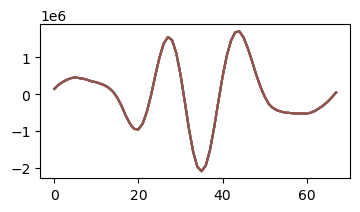

xy_.shape torch.Size([6, 2])
model TISRAW2BPMQ_model(
  (conv_res): Sequential(
    (0): Conv1d(1, 4, kernel_size=(9,), stride=(5,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(4, 2, kernel_size=(8,), stride=(5,))
    (3): ELU(alpha=1.0)
  )
  (conv): Sequential(
    (0): Conv1d(1, 1, kernel_size=(7,), stride=(4,))
    (1): ELU(alpha=1.0)
    (2): Conv1d(1, 2, kernel_size=(5,), stride=(2,))
    (3): ELU(alpha=1.0)
    (4): Conv1d(2, 2, kernel_size=(4,), stride=(1,))
    (5): ELU(alpha=1.0)
    (6): Conv1d(2, 2, kernel_size=(3,), stride=(1,))
    (7): ELU(alpha=1.0)
  )
  (nn_xy): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (nn_res): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (nn): Se

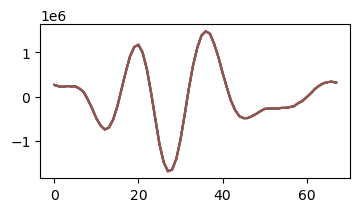

xy_.shape torch.Size([6, 2])


,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5565:beamQ
timestamp,,
2025-02-26 08:25:28.600,13.346640,8.402332
2025-02-26 08:25:28.800,13.346420,8.401880
2025-02-26 08:25:29.000,13.345573,8.402345
2025-02-26 08:25:29.200,13.345565,8.402702
2025-02-26 08:25:29.400,13.303609,8.369059
2025-02-26 08:25:29.600,13.302732,8.368627


In [8]:
df = bpmQscan.quads_evaluator.read()

In [9]:
bpmQscan.quads_evaluator.fetch_data_monitors

['BDS_BTS:BPM_D5513:CURRENT_RD',
 'BDS_BTS:BPM_D5513:TISRAW1_RD',
 'BDS_BTS:BPM_D5513:TISRAW4_RD',
 'BDS_BTS:BPM_D5565:TISRAW1_RD',
 'BDS_BTS:PSQ_D5509:I_RD',
 'BDS_BTS:BPM_D5513:MAG_RD',
 'BDS_BTS:BPM_D5513:XPOS_RD',
 'BDS_BTS:BPM_D5565:TISMAG161_3_RD',
 'BDS_BTS:BPM_D5565:MAG_RD',
 'BDS_BTS:PSC2_D5496:I_CSET',
 'BDS_BTS:BPM_D5565:XPOS_RD',
 'BDS_BTS:PSC1_D5496:I_CSET',
 'BDS_BTS:PSC2_D5496:I_RD',
 'BDS_BTS:BPM_D5565:TISMAG161_4_RD',
 'BDS_BTS:PSQ_D5501:I_RD',
 'BDS_BTS:BPM_D5513:TISMAG161_1_RD',
 'BDS_BTS:BPM_D5565:TISRAW2_RD',
 'BDS_BTS:BPM_D5513:TISRAW2_RD',
 'BDS_BTS:BPM_D5513:TISMAG161_2_RD',
 'BDS_BTS:BPM_D5513:PHASE_RD',
 'BDS_BTS:BPM_D5565:TISMAG161_2_RD',
 'BDS_BTS:PSQ_D5501:I_CSET',
 'BDS_BTS:PSC1_D5563:I_RD',
 'BDS_BTS:BPM_D5513:TISMAG161_3_RD',
 'BDS_BTS:PSC2_D5563:I_RD',
 'BDS_BTS:BPM_D5565:CURRENT_RD',
 'BDS_BTS:PSC1_D5563:I_CSET',
 'BDS_BTS:BPM_D5565:YPOS_RD',
 'BDS_BTS:PSC1_D5496:I_RD',
 'BDS_BTS:BPM_D5565:TISRAW3_RD',
 'BDS_BTS:BPM_D5513:YPOS_RD',
 'BDS_BTS:BPM_D5513:

In [10]:
import pickle
pickle.dump(df,open('df.pkl','wb'))

In [2]:
import pickle
df = pickle.load(open('df.pkl','rb'))
df

,BDS_BTS:BPM_D5513:CURRENT_RD,BDS_BTS:BPM_D5513:TISRAW1_RD,BDS_BTS:BPM_D5513:TISRAW4_RD,BDS_BTS:BPM_D5565:TISRAW1_RD,BDS_BTS:PSQ_D5509:I_RD,BDS_BTS:BPM_D5513:MAG_RD,BDS_BTS:BPM_D5513:XPOS_RD,BDS_BTS:BPM_D5565:TISMAG161_3_RD,BDS_BTS:BPM_D5565:MAG_RD,BDS_BTS:PSC2_D5496:I_CSET,...,BDS_BTS:BPM_D5513:U3,BDS_BTS:BPM_D5513:U4,BDS_BTS:BPM_D5565:U1,BDS_BTS:BPM_D5565:U2,BDS_BTS:BPM_D5565:U3,BDS_BTS:BPM_D5565:U4,BDS_BTS:BPM_D5513:beamQ,BDS_BTS:BPM_D5513:beamQ_model_err,BDS_BTS:BPM_D5565:beamQ,BDS_BTS:BPM_D5565:beamQ_model_err
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-02-26 08:25:28.600,20.930787,"[143906.52941176458, 256311.4117647058, 330392...","[105663.67647058824, 212451.29411764705, 31176...","[262821.67647058825, 233131.82352941178, 21791...",55.966,1.906299,1.070685,33083.434615,1.851282,10.0,...,9.969338e+08,8.119829e+08,7.228149e+08,8.381980e+08,9.444328e+08,7.958450e+08,13.346640,6.021052,8.402332,5.796093
2025-02-26 08:25:28.800,20.937655,"[143906.52941176458, 256311.4117647058, 330392...","[105663.67647058824, 212451.29411764705, 31176...","[262821.67647058825, 233131.82352941178, 21791...",55.966,1.906925,1.070846,33083.434615,1.852490,10.0,...,9.969338e+08,8.119829e+08,7.228149e+08,8.381980e+08,9.444328e+08,7.958450e+08,13.346420,6.021059,8.401880,5.796908
2025-02-26 08:25:29.000,20.925140,"[143906.52941176458, 256311.4117647058, 330392...","[105663.67647058824, 212451.29411764705, 31176...","[262821.67647058825, 233131.82352941178, 21791...",55.966,1.905785,1.071442,33083.434615,1.852092,10.0,...,9.969338e+08,8.119829e+08,7.228149e+08,8.381980e+08,9.444328e+08,7.958450e+08,13.345573,6.021088,8.402345,5.795939
2025-02-26 08:25:29.200,20.921412,"[143906.52941176458, 256311.4117647058, 330392...","[105663.67647058824, 212451.29411764705, 31176...","[262821.67647058825, 233131.82352941178, 21791...",55.966,1.905445,1.070306,33083.434615,1.851259,10.0,...,9.969338e+08,8.119829e+08,7.228149e+08,8.381980e+08,9.444328e+08,7.958450e+08,13.345565,6.021088,8.402702,5.796068
2025-02-26 08:25:29.400,20.926883,"[143438.205882353, 256302.5882352942, 330161.2...","[105261.26470588236, 213017.9117647059, 311700...","[263204.14705882355, 233971.29411764708, 21779...",55.966,1.905943,1.074550,33132.777917,1.849973,10.0,...,9.987564e+08,8.127788e+08,7.233329e+08,8.388067e+08,9.458414e+08,7.966425e+08,13.303609,6.055672,8.369059,5.818163
2025-02-26 08:25:29.600,20.929556,"[143438.205882353, 256302.5882352942, 330161.2...","[105261.26470588236, 213017.9117647059, 311700...","[263204.14705882355, 233971.29411764708, 21779...",55.966,1.906187,1.074982,33132.777917,1.851749,10.0,...,9.987564e+08,8.127788e+08,7.233329e+08,8.388067e+08,9.458414e+08,7.966425e+08,13.302732,6.055711,8.368627,5.820085


In [11]:
from epics import caget_many

In [12]:
single_shot = caget_many([
    'BDS_BTS:BPM_D5513:CURRENT_RD',
    'BDS_BTS:BPM_D5513:TISRAW1_RD',
    'BDS_BTS:BPM_D5513:TISRAW4_RD',
    'BDS_BTS:BPM_D5565:TISRAW1_RD',
    'BDS_BTS:PSQ_D5509:I_RD',
    'BDS_BTS:BPM_D5513:MAG_RD',
    'BDS_BTS:BPM_D5513:XPOS_RD',
    'BDS_BTS:BPM_D5565:TISMAG161_3_RD',
    'BDS_BTS:BPM_D5565:MAG_RD',
    'BDS_BTS:PSC2_D5496:I_CSET',
    'BDS_BTS:BPM_D5565:XPOS_RD',
    'BDS_BTS:PSC1_D5496:I_CSET',
    'BDS_BTS:PSC2_D5496:I_RD',
    'BDS_BTS:BPM_D5565:TISMAG161_4_RD',
    'BDS_BTS:PSQ_D5501:I_RD',
    'BDS_BTS:BPM_D5513:TISMAG161_1_RD',
    'BDS_BTS:BPM_D5565:TISRAW2_RD',
    'BDS_BTS:BPM_D5513:TISRAW2_RD',
    'BDS_BTS:BPM_D5513:TISMAG161_2_RD',
    'BDS_BTS:BPM_D5513:PHASE_RD',
    'BDS_BTS:BPM_D5565:TISMAG161_2_RD',
    'BDS_BTS:PSQ_D5501:I_CSET',
    'BDS_BTS:PSC1_D5563:I_RD',
    'BDS_BTS:BPM_D5513:TISMAG161_3_RD',
    'BDS_BTS:PSC2_D5563:I_RD',
    'BDS_BTS:BPM_D5565:CURRENT_RD',
    'BDS_BTS:PSC1_D5563:I_CSET',
    'BDS_BTS:BPM_D5565:YPOS_RD',
    'BDS_BTS:PSC1_D5496:I_RD',
    'BDS_BTS:BPM_D5565:TISRAW3_RD',
    'BDS_BTS:BPM_D5513:YPOS_RD',
    'BDS_BTS:BPM_D5513:TISRAW3_RD',
    'BDS_BTS:BPM_D5565:PHASE_RD',
    'BDS_BTS:PSQ_D5509:I_CSET',
    'BDS_BTS:BPM_D5513:TISMAG161_4_RD',
    'BDS_BTS:BPM_D5565:TISRAW4_RD',
    'BDS_BTS:BPM_D5565:TISMAG161_1_RD',
    'BDS_BTS:PSC2_D5563:I_CSET'])

In [13]:
single_shot

[21.015919502553874,
 array([  143692.94117647,   257064.47058824,   331320.94117647,
          392130.47058824,   437334.94117647,   454141.47058824,
          436206.94117647,   419411.47058824,   383765.94117647,
          345787.47058824,   324240.94117647,   284531.47058824,
          238294.94117647,   169069.47058824,    60107.94117647,
         -101035.52941176,  -321540.05882353,  -586571.52941176,
         -807208.05882353,  -946420.52941176,  -959093.05882353,
         -806868.52941176,  -482537.05882353,   -30572.52941176,
          500959.94117647,   996605.47058824,  1375131.94117647,
         1553645.47058824,  1472933.94117647,  1117526.47058824,
          533877.94117647,  -185577.52941176,  -935604.05882353,
        -1562357.52941176, -1972105.05882353, -2098416.52941176,
        -1947547.05882353, -1528217.52941176,  -910711.05882353,
         -205375.52941176,   472646.94117647,  1040687.47058824,
         1455000.94117647,  1683767.47058824,  1710562.94117647,
    

In [ ]:
# plt.plot(bpmQscan.evaluated_dfs[0][0]['BDS_BTS:BPM_D5513:TISRAW3_RD'].iloc[0])

In [ ]:
# l_xcovs, l_ycovs = fmlat.update_lattice_file_from_bpmQscan(filename,bpmQscan)

In [ ]:
# bpmQscan.save_data(fname+'.pkl')

In [ ]:
bpmQscan.model.cs.detach().cpu().numpy()

In [ ]:
bpmQscan.get_data().keys()

In [ ]:
bpmQscan.plot_reconstructed_ellipse()

In [ ]:
len(bpmQscan.train_llB2)

In [ ]:
bpmQscan.cs_ref